# **K Means Clustering**

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
data = pd.read_csv('sample_1.csv')

In [ ]:
data.dtypes

,0
c1,float64
c2,float64


In [ ]:
data.isna().sum()

,0
c1,0
c2,0


In [ ]:
data.shape

(300, 2)

In [ ]:
data.drop_duplicates(inplace=True)
data.shape

(300, 2)

In [ ]:
# Not Recommended to do standardization before clustering , as when we standardize the data comes in a range and it's impossible to bifurcate data points

In [ ]:
X = data

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.3, random_state=7) # random state value - 0 to 2^31

X_train.shape, X_test.shape

((210, 2), (90, 2))

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# How we decide right k in k-means?

- Elbow method : iterate k-means with different value of k from (0 to 10)
                 and we check the inertia (Angle close to 90)

In [ ]:
# Step 1 :  Create the object
km = KMeans(n_clusters=3, random_state=7, max_iter=100)
# Step 2: fit
km.fit(X_train)


KMeans(max_iter=100, n_clusters=3, random_state=7)

In [ ]:
km.cluster_centers_

array([[-6.89102241, -7.04992131],
       [-2.65392001,  9.04028015],
       [ 4.52734878,  2.04376566]])

In [ ]:
# Step 3: Predict
y_pred = km.predict(X_test)

In [ ]:
# silhouette score:
print(silhouette_score(X_test,y_pred))

0.8148470997055839


# Agglomerative Clustering

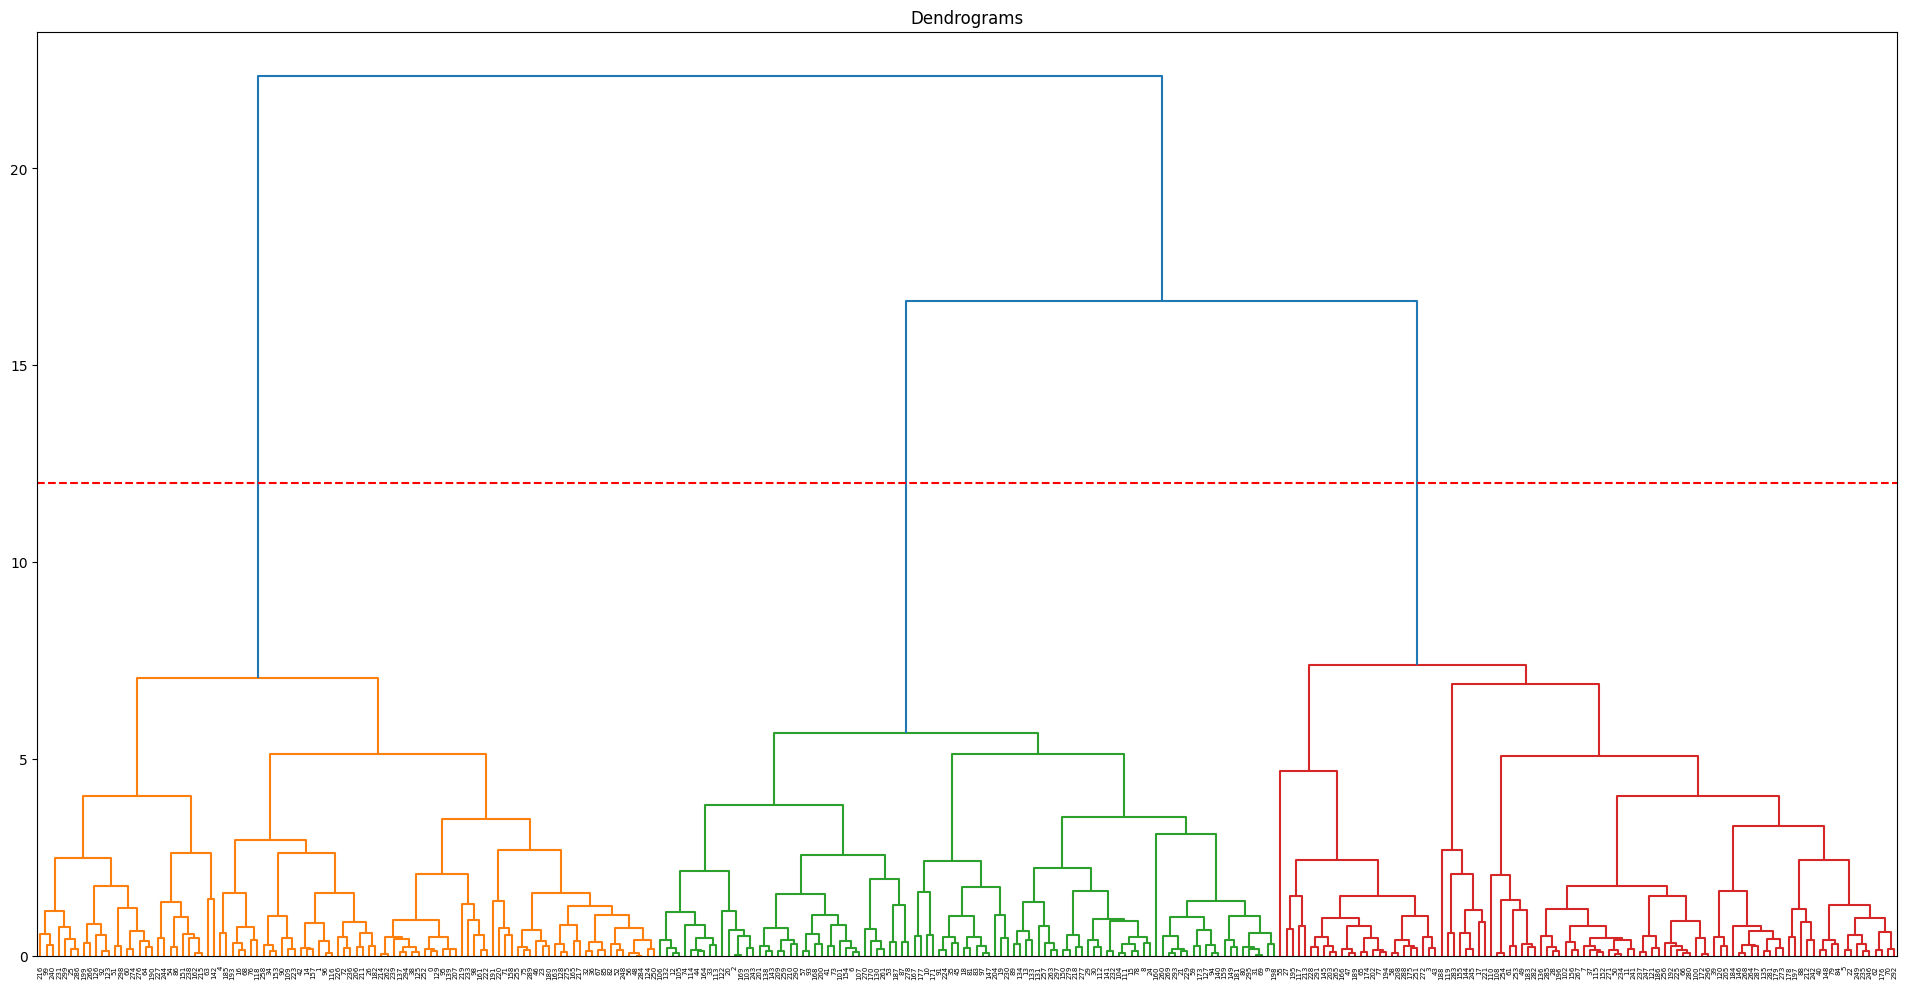

In [ ]:
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as shc
plt.figure(figsize=(24, 12))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X.iloc[:500,:], method='complete'))
plt.axhline(y=12, color='r', linestyle='--')
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=3)
ac.fit(X_train)
#y_pred = ac.predict(X_train)  # Not present
#cannot predict on new data
y_pred = ac.fit_predict(X_train) # Same data it will fit & on same data it will predict

# Take Data MR2
- Preprocess
- Apply K-Means
- find silhoutte score

In [ ]:
df = pd.read_csv('/content/data_MR_2.csv')
#
#
df.head()

,cut,x,y,z
0,Ideal,3.95,3.98,2.43
1,Premium,3.89,3.84,2.31
2,Good,4.05,4.07,2.31
3,Premium,4.20,4.23,2.63
4,Good,4.34,4.35,2.75


In [ ]:
df.columns

Index(['cut', 'x', 'y', 'z'], dtype='object')

In [ ]:
df['cut'].unique() #NOMINAL

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [ ]:
df.shape

(53940, 4)

In [ ]:
df.isna().sum()

,0
cut,0
x,0
y,0
z,0


In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(42907, 4)

In [ ]:
df_ohe = pd.get_dummies(df)
df_ohe.head()

,x,y,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Good
0,3.95,3.98,2.43,False,False,True,False,False
1,3.89,3.84,2.31,False,False,False,True,False
2,4.05,4.07,2.31,False,True,False,False,False
3,4.20,4.23,2.63,False,False,False,True,False
4,4.34,4.35,2.75,False,True,False,False,False


In [ ]:
df_ohe.columns

Index(['x', 'y', 'z', 'cut_Fair', 'cut_Good', 'cut_Ideal', 'cut_Premium',
       'cut_Very Good'],
      dtype='object')

In [ ]:
X = df_ohe

In [ ]:

X_train, X_test = train_test_split(X, test_size=0.3, random_state=7)
X_train.shape, X_test.shape

((30034, 8), (12873, 8))

In [ ]:
# K-Means
km = KMeans(n_clusters=3, random_state=7, max_iter=100)
km.fit(X_train)
y_pred = km.predict(X_test)
# silhouette Score
print(silhouette_score(X_test,y_pred))
#

0.37595154796047014
